# NASA Web Log Analytics

This notebook demonstrates the analysis workflow for the NASA August 1995 web
server access logs.

The reusable parsing and aggregation logic is kept in the `src/` package rather
than being implemented directly in the notebook. This keeps the project modular,
testable, and usable from both notebooks and command-line scripts.

## Questions explored

1. How many valid and malformed records are present?
2. Which resources received the most `GET` requests?
3. Which day had the highest request volume?
4. How are HTTP status codes distributed?
5. What are the response-size characteristics?


## Dataset setup

Download the dataset from:

https://drive.google.com/file/d/1ZiyXLVDyirV_2OivNVdTqeUPQ5ez7M2a/view

Save it as:

```text
data/nasa_access_log_aug95_sample.txt
```

Run the notebook from either the repository root or the `notebooks/` directory.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Support running the notebook from the repository root or notebooks/ directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from nasa_log_analytics.analytics import analyse_records
from nasa_log_analytics.parser import read_log_records

DATA_PATH = PROJECT_ROOT / "data" / "nasa_access_log_aug95_sample.txt"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Download it using the link in the Dataset setup section."
    )

DATA_PATH


Matplotlib is building the font cache; this may take a moment.


WindowsPath('c:/Users/aadin/Coding/nasa-log-analytics/data/nasa_access_log_aug95_sample.txt')

## 1. Parse the raw access log

The parser reads the Apache Common Log Format directly. Invalid records are
counted instead of causing the entire pipeline to fail.


In [2]:
records, malformed_lines = read_log_records(DATA_PATH)

print(f"Valid records: {len(records):,}")
print(f"Malformed records: {malformed_lines:,}")


Valid records: 99,783
Malformed records: 120


A parsed record contains the host, timestamp, HTTP method, requested path,
protocol, response status, and response size.


In [3]:
sample_records = pd.DataFrame([record.as_dict() for record in records[:5]])
sample_records


,host,timestamp,method,path,protocol,status,size
0,159.142.165.138,1995-08-15T11:03:22-04:00,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200,4179
1,134.131.38.18,1995-08-22T13:43:38-04:00,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200,4179
2,os2c14.aca.ilstu.edu,1995-08-31T21:47:11-04:00,GET,/shuttle/missions/sts-69/sts-69-patch-small.gif,HTTP/1.0,200,8083
3,suba01.suba.com,1995-08-24T04:48:23-04:00,GET,/htbin/wais.pl?TISP,HTTP/1.0,200,1349
4,146.138.145.170,1995-08-08T16:30:51-04:00,GET,/shuttle/missions/sts-62/sts-62-patch-small.gif,HTTP/1.0,200,14385


## 2. Calculate summary statistics

The same reusable analytics function is used by the command-line interface.


In [4]:
summary = analyse_records(
    records,
    malformed_lines=malformed_lines,
    top_n=10,
)

summary


{'total_records': 99783,
 'malformed_lines': 120,
 'top_get_paths': [('/images/NASA-logosmall.gif', 6193),
  ('/images/KSC-logosmall.gif', 4917),
  ('/images/MOSAIC-logosmall.gif', 4216),
  ('/images/WORLD-logosmall.gif', 4212),
  ('/images/USA-logosmall.gif', 4210),
  ('/images/ksclogo-medium.gif', 3942),
  ('/ksc.html', 2781),
  ('/history/apollo/images/apollo-logo1.gif', 2378),
  ('/images/launch-logo.gif', 2194),
  ('/images/ksclogosmall.gif', 1846)],
 'busiest_day': {'date': '1995-08-31', 'requests': 5710},
 'status_counts': {200: 88883,
  302: 1643,
  304: 8596,
  403: 12,
  404: 647,
  501: 2},
 'successful_responses': 88883,
 'non_200_responses': 10900,
 'response_size_bytes': {'minimum': 0,
  'maximum': 3155499,
  'average': 17453.837537167015}}

## 3. Most requested resources

Only `GET` requests are included in this ranking.


In [5]:
top_paths = pd.DataFrame(
    summary["top_get_paths"],
    columns=["path", "requests"],
)

top_paths


,path,requests
0,/images/NASA-logosmall.gif,6193
1,/images/KSC-logosmall.gif,4917
2,/images/MOSAIC-logosmall.gif,4216
3,/images/WORLD-logosmall.gif,4212
4,/images/USA-logosmall.gif,4210
5,/images/ksclogo-medium.gif,3942
6,/ksc.html,2781
7,/history/apollo/images/apollo-logo1.gif,2378
8,/images/launch-logo.gif,2194
9,/images/ksclogosmall.gif,1846


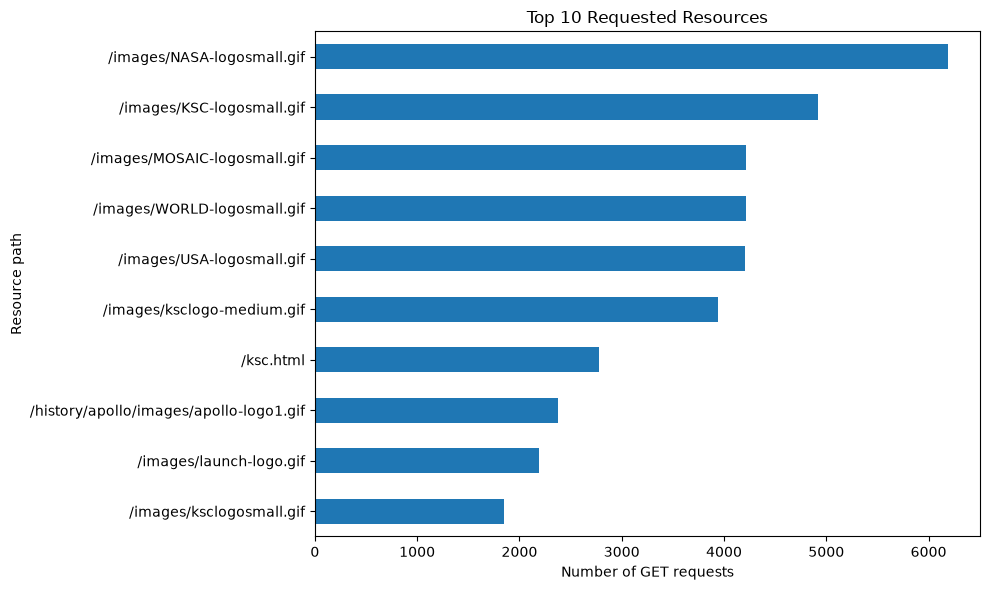

In [6]:
plot_data = top_paths.sort_values("requests")

ax = plot_data.plot.barh(
    x="path",
    y="requests",
    legend=False,
    figsize=(10, 6),
    title="Top 10 Requested Resources",
)
ax.set_xlabel("Number of GET requests")
ax.set_ylabel("Resource path")
plt.tight_layout()
plt.show()


## 4. HTTP status-code distribution

Status codes show how many requests succeeded, redirected, or failed.


In [7]:
status_counts = pd.DataFrame(
    sorted(summary["status_counts"].items()),
    columns=["status", "requests"],
)

status_counts


,status,requests
0,200,88883
1,302,1643
2,304,8596
3,403,12
4,404,647
5,501,2


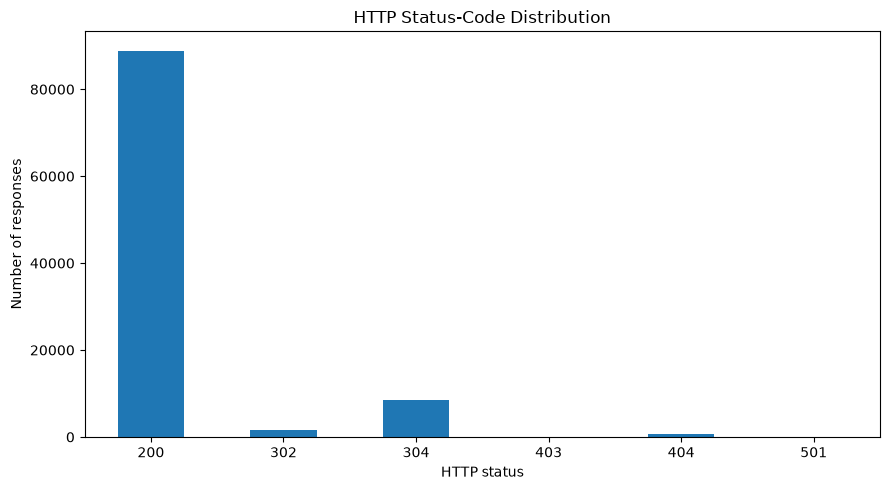

In [8]:
ax = status_counts.plot.bar(
    x="status",
    y="requests",
    legend=False,
    figsize=(9, 5),
    title="HTTP Status-Code Distribution",
)
ax.set_xlabel("HTTP status")
ax.set_ylabel("Number of responses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Request volume by day

The next calculation uses the parsed timestamps to identify daily traffic
patterns.


In [9]:
request_dates = pd.Series(
    [record.timestamp.date() for record in records],
    name="date",
)

requests_by_day = (
    request_dates.value_counts()
    .sort_index()
    .rename_axis("date")
    .reset_index(name="requests")
)

requests_by_day.head()


,date,requests
0,1995-08-01,2144
1,1995-08-03,2575
2,1995-08-04,3762
3,1995-08-05,1944
4,1995-08-06,2094


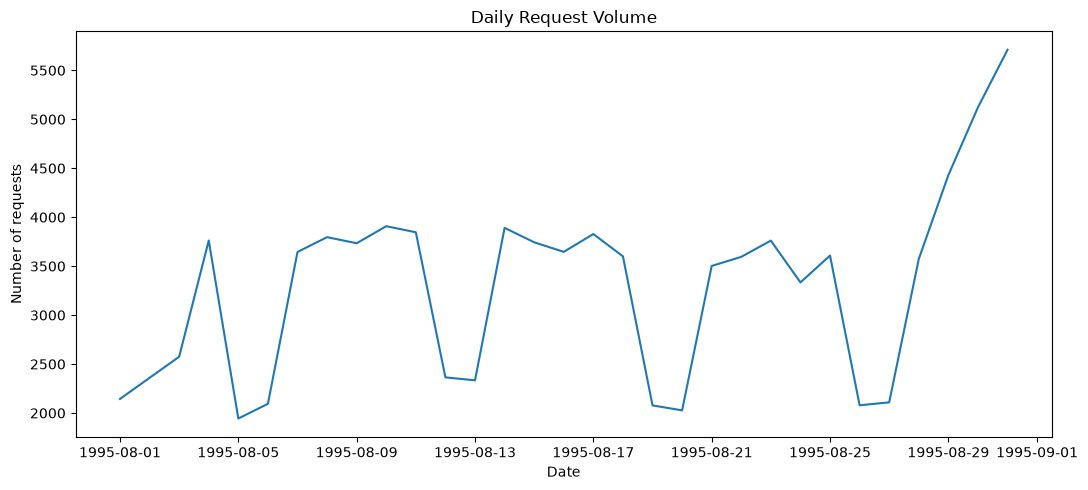

In [10]:
ax = requests_by_day.plot.line(
    x="date",
    y="requests",
    legend=False,
    figsize=(11, 5),
    title="Daily Request Volume",
)
ax.set_xlabel("Date")
ax.set_ylabel("Number of requests")
plt.tight_layout()
plt.show()


In [11]:
busiest_day = summary["busiest_day"]

print(
    f"Busiest day: {busiest_day['date']} "
    f"with {busiest_day['requests']:,} requests"
)


Busiest day: 1995-08-31 with 5,710 requests


## 6. Response-size statistics

Missing response sizes are excluded from the minimum, maximum, and average.


In [12]:
response_sizes = pd.Series(
    [record.size for record in records if record.size is not None],
    name="response_size_bytes",
)

response_sizes.describe()


count    9.887800e+04
mean     1.745384e+04
std      7.056104e+04
min      0.000000e+00
25%      6.690000e+02
50%      3.260000e+03
75%      9.630000e+03
max      3.155499e+06
Name: response_size_bytes, dtype: float64

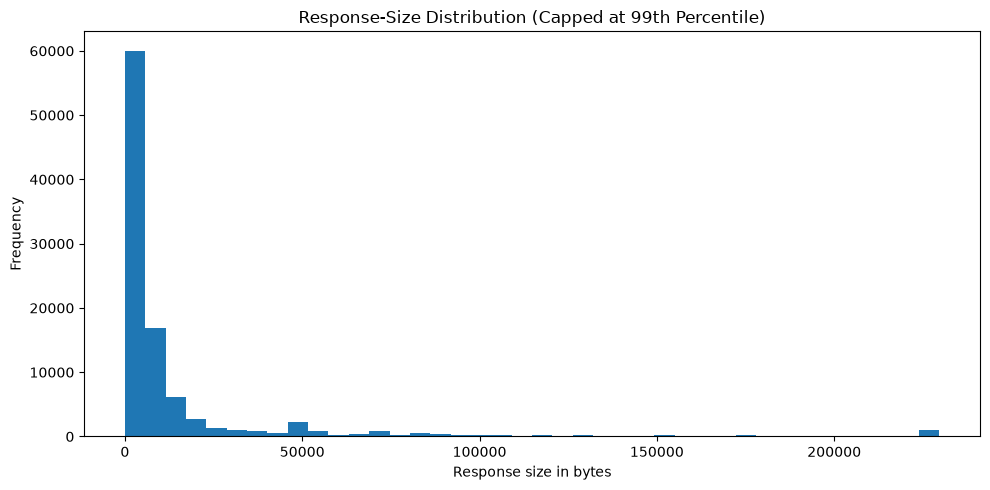

In [13]:
ax = response_sizes.clip(upper=response_sizes.quantile(0.99)).plot.hist(
    bins=40,
    figsize=(10, 5),
    title="Response-Size Distribution (Capped at 99th Percentile)",
)
ax.set_xlabel("Response size in bytes")
plt.tight_layout()
plt.show()


## Key findings

After running the notebook, use the generated tables and charts to summarize:

- the most frequently requested resource;
- the busiest traffic day;
- the proportion of successful and unsuccessful responses;
- the typical response size and any extreme values.

The standard-Python implementation is suitable for this sample dataset. The
separate PySpark job in `src/spark_job.py` expresses the same workflow using
distributed DataFrame operations for larger-scale processing.
